In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import  matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import PowerTransformer,OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.metrics import roc_curve,roc_auc_score
df = pd.read_csv('/content/patient_adherence_dataset.csv')
df_original = df.copy()
print('\nDataset_information')
print('---------')
df.head(5)





Dataset_information
---------


,Age,Gender,Medication_Type,Dosage_mg,Previous_Adherence,Education_Level,Income,Social_Support_Level,Condition_Severity,Comorbidities_Count,Healthcare_Access,Mental_Health_Status,Insurance_Coverage,Adherence
0,57,Male,TypeA,136,1,High School,634934,Medium,Severe,3,Poor,Good,1,1
1,47,Male,TypeA,134,1,High School,297954,High,Moderate,3,Good,Good,1,0
2,59,Male,TypeC,89,1,High School,789337,High,Moderate,1,Good,Good,1,1
3,72,Male,TypeB,240,0,Postgraduate,267352,Low,Mild,2,Poor,Moderate,1,0
4,46,Male,TypeA,241,1,Postgraduate,718447,Medium,Mild,1,Poor,Good,1,0


In [2]:
df['Adherence'].value_counts()
# Balanced Dataset

,count
Adherence,
0,2714
1,2286


In [ ]:
print(df.info())
print('Dataset_Shape:',df.shape)
print(df.select_dtypes(include=['int64' or 'float64']).skew())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   5000 non-null   int64 
 1   Gender                5000 non-null   object
 2   Medication_Type       5000 non-null   object
 3   Dosage_mg             5000 non-null   int64 
 4   Previous_Adherence    5000 non-null   int64 
 5   Education_Level       5000 non-null   object
 6   Income                5000 non-null   int64 
 7   Social_Support_Level  5000 non-null   object
 8   Condition_Severity    5000 non-null   object
 9   Comorbidities_Count   5000 non-null   int64 
 10  Healthcare_Access     5000 non-null   object
 11  Mental_Health_Status  5000 non-null   object
 12  Insurance_Coverage    5000 non-null   int64 
 13  Adherence             5000 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 547.0+ KB
None
Dataset_Shape: (5000, 14)
Age       

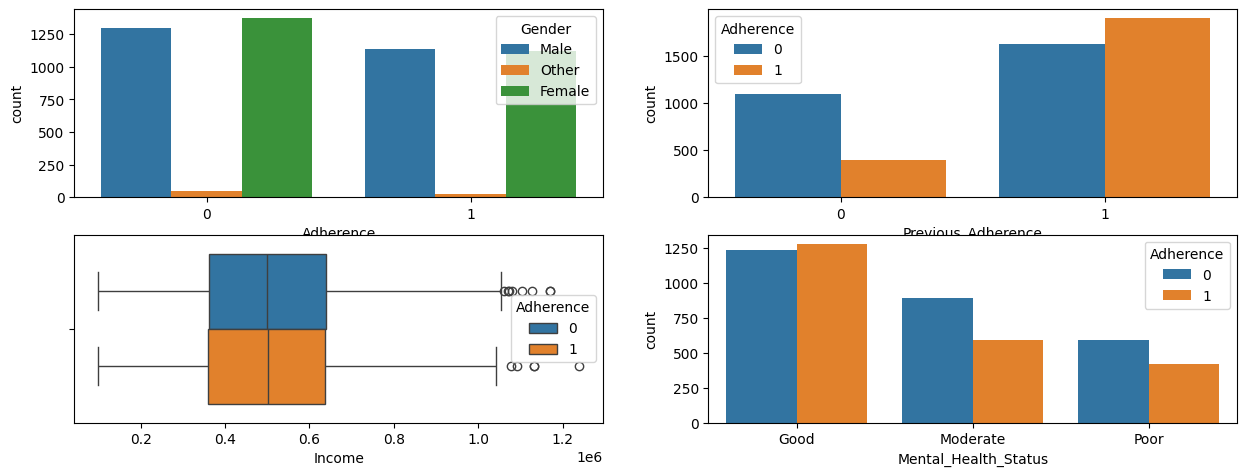

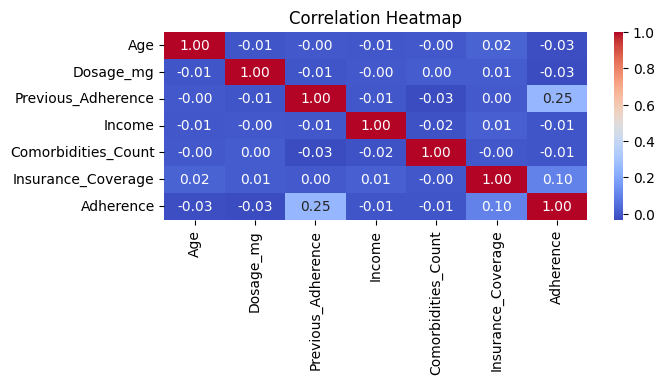

                 Age         Income   Dosage_mg  Previous_Adherence
Adherence                                                          
0          50.030582  502667.417097  202.360722            0.596168
1          49.232283  498840.928696  199.150481            0.828521


In [ ]:
#EDA
plt.figure(figsize=(15,20))
plt.subplot(7,2,1)
sns.countplot(x=df['Adherence'],hue = 'Gender',data = df)
plt.subplot(7,2,2)
sns.countplot(x='Previous_Adherence',
              hue='Adherence',
              data=df)
plt.subplot(7,2,3)
sns.boxplot( x= df['Income'],hue='Adherence',data = df)
plt.subplot(7,2,4)
sns.countplot(x='Mental_Health_Status',
              hue='Adherence',
              data=df)
plt.figure(figsize=(15,20))

corr = df.select_dtypes(include=['int64','float64']).corr()
plt.subplot(7,2,5)
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()
print(df.groupby('Adherence')[
    ['Age',
     'Income',
     'Dosage_mg',
     'Previous_Adherence']
].mean())
y = df['Adherence']
x = df.drop('Adherence',axis =1)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,random_state=42)

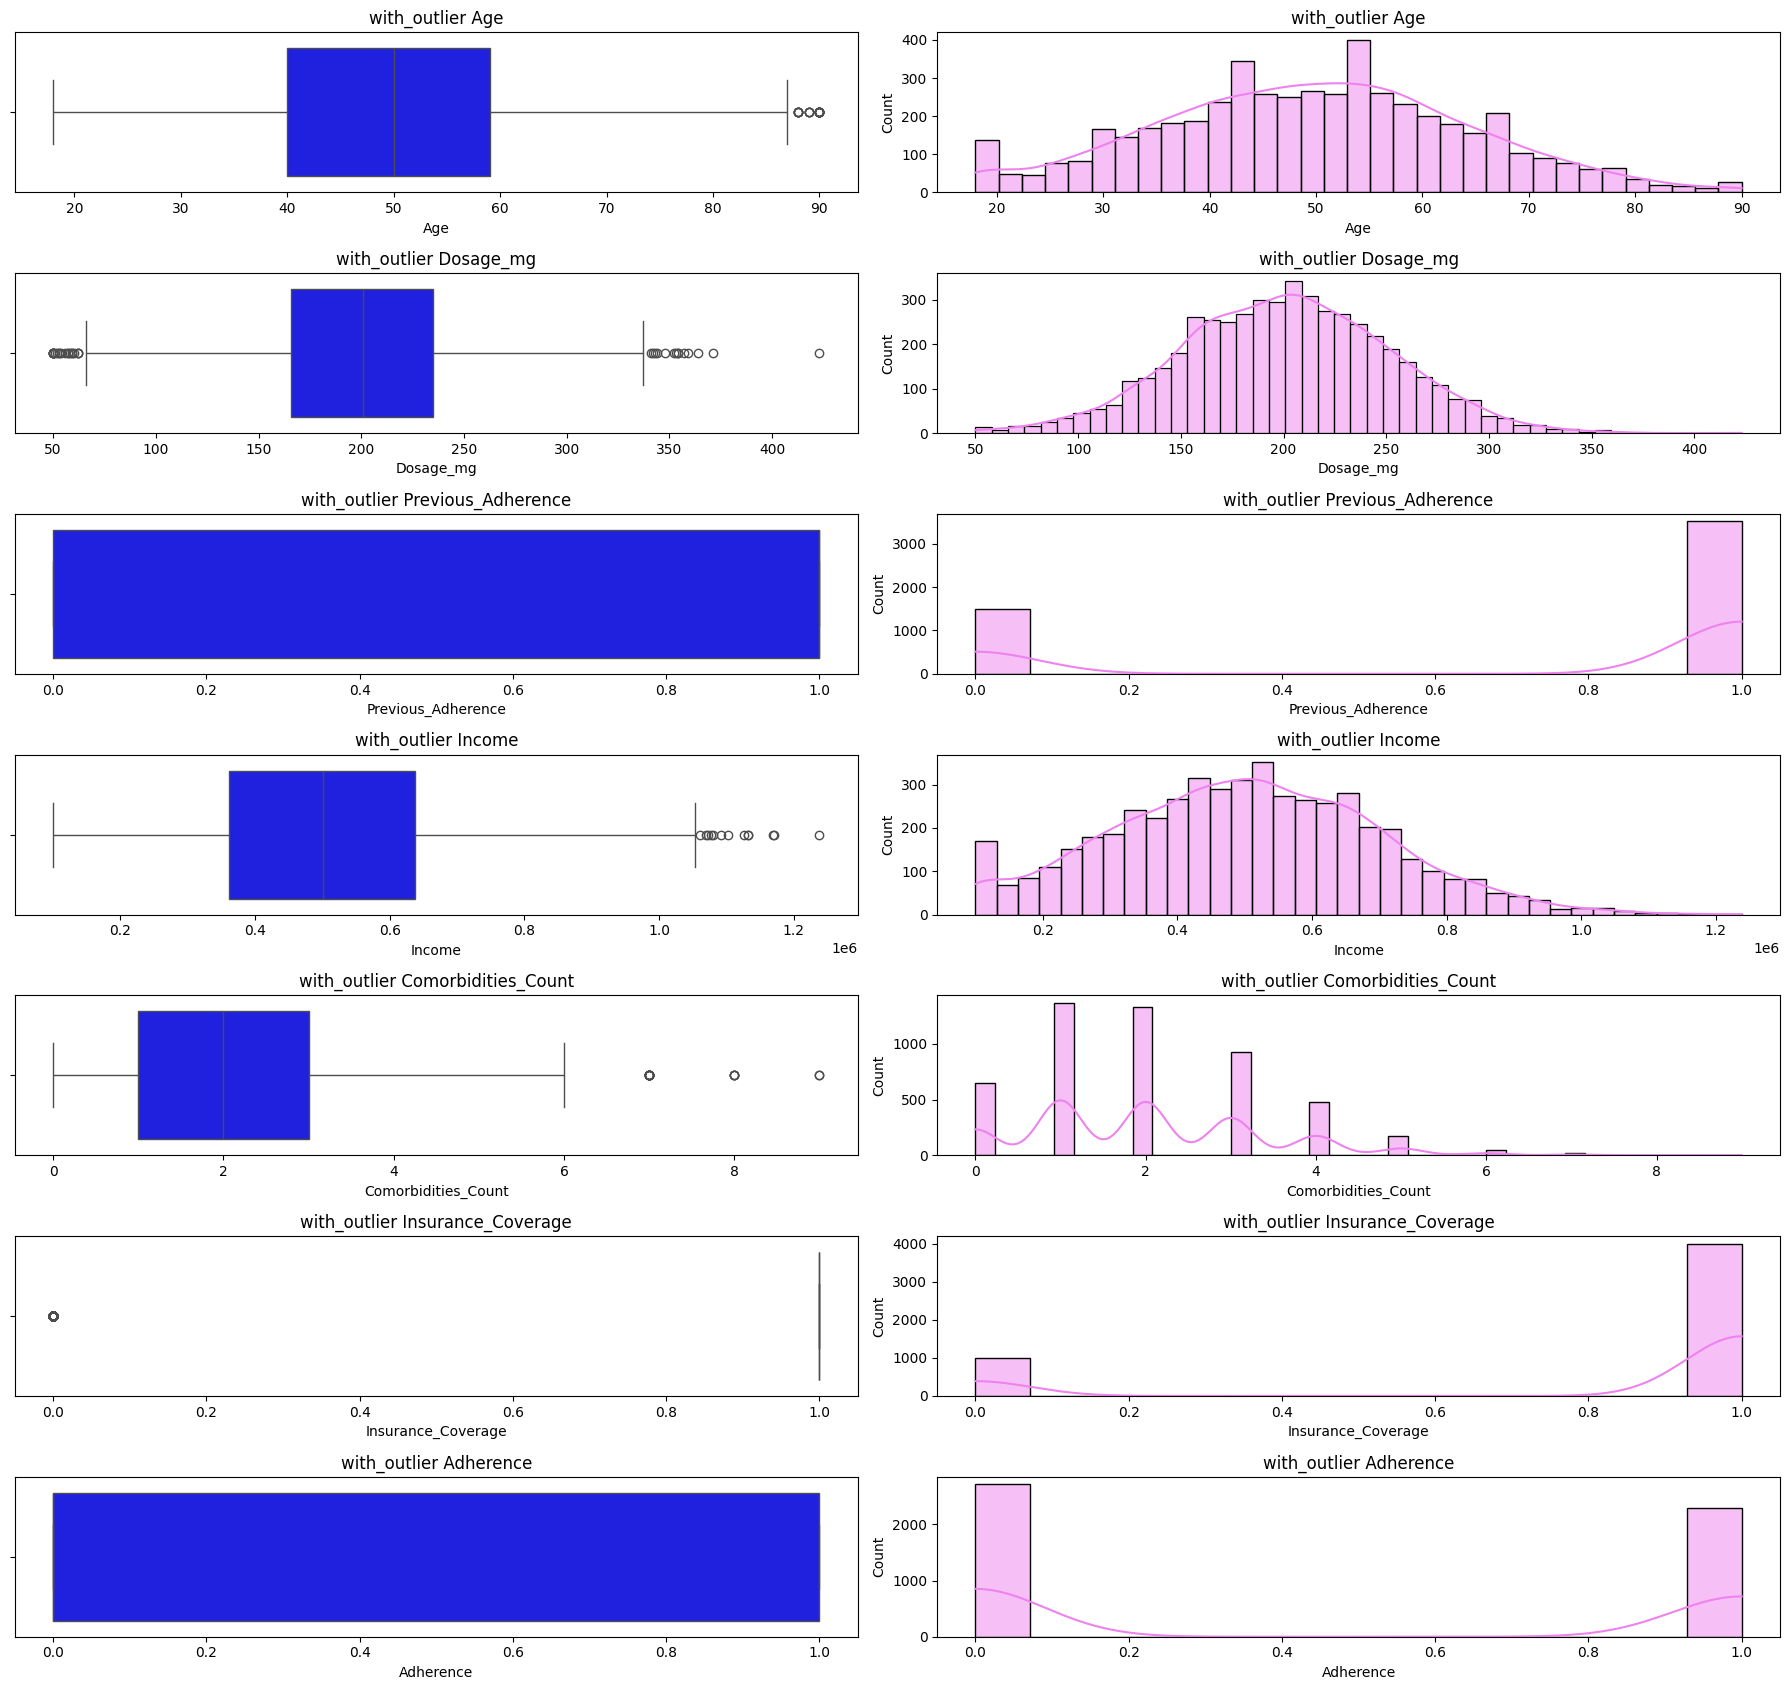


 Skewness_Values:
----------
Series([], dtype: float64)

 Null_Values
----------
Age                     0
Gender                  0
Medication_Type         0
Dosage_mg               0
Previous_Adherence      0
Education_Level         0
Income                  0
Social_Support_Level    0
Condition_Severity      0
Comorbidities_Count     0
Healthcare_Access       0
Mental_Health_Status    0
Insurance_Coverage      0
Adherence               0
dtype: int64


In [4]:
#outlier
num_col = df.select_dtypes(include=['int64']).columns
plt.figure(figsize=(18,17))
#BoxPlot to determine outliers
for i,col in enumerate(num_col):
  if df_original[col].dtype == 'int64':
    plt.subplot(len(num_col),2,2*i+1)
    sns.boxplot(x = df_original[col],data = df,color = 'blue')
    plt.title(f'with_outlier {col}')
for i,col in enumerate(num_col):
  if df_original[col].dtype == 'int64':
    plt.subplot(len(num_col),2,2*i+2)
    sns.histplot(x = df_original[col],data = df,kde= True,color = 'violet')
    plt.title(f'with_outlier {col}')
plt.tight_layout()
plt.show()
#skewness_checking
new_df = df.select_dtypes(include=['float64'])
print('\n Skewness_Values:')
print('----------')
print(new_df.skew())
print('\n Null_Values')
print('----------')
print(df.isnull().sum())
#FeatureEngineering
df['Mental_Health_Status'].unique()
y = df['Adherence']
x = df.drop('Adherence',axis =1)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,random_state=42)


In [16]:
#ordinalEncoding
print(df['Mental_Health_Status'].unique())
class outliercapper(BaseEstimator,TransformerMixin):
  def fit(self,x,y=None):
    q1 = np.percentile(x,25,axis=0)
    q3 = np.percentile(x,75,axis=0)
    self.lower = q1-1.5*(q3-q1)
    self.upper = q3+1.5*(q3-q1)
    return self
  def transform(self,x):
    x = np.clip(x,self.lower,self.upper)
    return x
  def get_feature_names_out(self, input_features=None):
        return input_features
#num_pipe = Pipeline([('outlier',outliercapper()),('power',PowerTransformer()),('scale',StandardScaler())])
#ord_pipe = Pipeline([('ord',OrdinalEncoder(categories=[['High School' ,'Graduate','Postgraduate'],['Low', 'Medium','High'],['Mild','Moderate','Severe']
                                                      # ,['Poor', 'Average', 'Good'],['Poor','Moderate','Good']]))])
ohe_pipe= Pipeline([('ohe',OneHotEncoder(sparse_output=False,handle_unknown='ignore'))])
preprocessor = ColumnTransformer([
                                                                        ('ohe',ohe_pipe,x_train.select_dtypes(include='object').columns.tolist())],remainder= 'passthrough')
main_pipe_1 = Pipeline([('preprocessor',preprocessor),('model',LogisticRegression())])
param_grid_1 = [

    {
        'model': [DecisionTreeClassifier()],
        'model__max_depth': [3, 5, 10, 20, None],
        'model__min_samples_split': [2, 5, 10]
    },

   {

 'model':[RandomForestClassifier()],
 'model__n_estimators':[100,200,300],
 'model__max_depth':[5,10,15,None],
 'model__min_samples_split':[2,5,10],
 'model__min_samples_leaf':[1,2,4]

}
    ,{
    "model":[GradientBoostingClassifier(random_state=42)],
    "model__n_estimators":[100,200],
    "model__learning_rate":[0.05,0.1],
    "model__max_depth":[3,5]
},


{
    "model":[SVC(probability=True)],
    "model__C":[0.1,1,10],
    "model__kernel":["rbf"]
}

]
grid1 = RandomizedSearchCV(estimator=main_pipe_1,param_distributions= param_grid_1,cv = 5,scoring ='accuracy',n_jobs = -1)
grid1.fit(x_train,y_train)
print('best_estimator:',grid1.best_estimator_)
print('best_socre of the model:',grid1.best_score_)

['Good' 'Moderate' 'Poor']
best_estimator: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Gender', 'Medication_Type',
                                                   'Education_Level',
                                                   'Social_Support_Level',
                                                   'Condition_Severity',
                                                   'Healthcare_Access',
                                                   'Mental_Health_Status'])])),
                ('model',
                 RandomForestClassifier(max_d

In [18]:
#Using Boosting Algorithms
main_pipe_2 = Pipeline([('preprocessor',preprocessor),('model',XGBClassifier())])
param_grid_2 = [{
    'model':[XGBClassifier()],
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__min_child_weight': [1, 3, 5],
    'model__gamma': [0, 0.1, 0.3, 0.5],
    'model__reg_alpha': [0, 0.01, 0.1, 1],
    'model__reg_lambda': [1, 2, 5, 10]

}]
grid2= RandomizedSearchCV(estimator=main_pipe_2,param_distributions=param_grid_2,cv=5,scoring='accuracy',n_jobs=-1)
grid2.fit(x_train,y_train)
print('best_estimator:',grid2.best_estimator_)
print('best_socre of the model:',grid2.best_score_)

best_estimator: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Gender', 'Medication_Type',
                                                   'Education_Level',
                                                   'Social_Support_Level',
                                                   'Condition_Severity',
                                                   'Healthcare_Access',
                                                   'Mental_Health_Status'])])),
                ('model',
                 XGBClassifier(base_scor...
                            

accuracy_score: 0.646
classification_report:               precision    recall  f1-score   support

           0       0.64      0.76      0.70       806
           1       0.65      0.51      0.57       694

    accuracy                           0.65      1500
   macro avg       0.65      0.64      0.64      1500
weighted avg       0.65      0.65      0.64      1500



<Axes: >

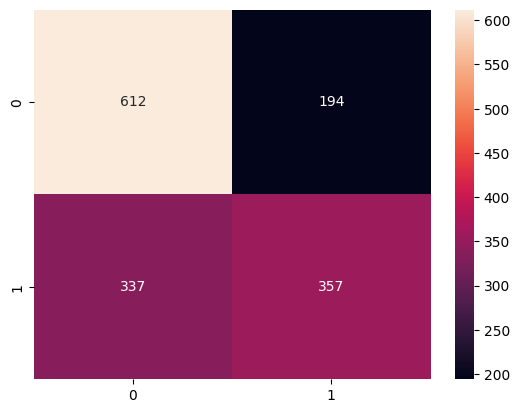

In [20]:
#Prediction
y_pred = grid1.predict(x_test)
print('accuracy_score:',accuracy_score(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))
cm  = confusion_matrix(y_test,y_pred)
#plotting Confusion_Matrix
sns.heatmap(cm,annot = True,fmt = 'd')

                         features  importance
23             Previous_Adherence    0.341490
22                      Dosage_mg    0.080553
24                         Income    0.063695
9       Social_Support_Level_High    0.056681
21                            Age    0.055654
26             Insurance_Coverage    0.055644
18      Mental_Health_Status_Good    0.046628
8    Education_Level_Postgraduate    0.045932
12        Condition_Severity_Mild    0.044381
16         Healthcare_Access_Good    0.036853
25            Comorbidities_Count    0.031367
19  Mental_Health_Status_Moderate    0.020910
15      Healthcare_Access_Average    0.018766
13    Condition_Severity_Moderate    0.014120
10       Social_Support_Level_Low    0.011274
6        Education_Level_Graduate    0.008844
14      Condition_Severity_Severe    0.008633
4           Medication_Type_TypeB    0.008572
20      Mental_Health_Status_Poor    0.007705
5           Medication_Type_TypeC    0.006572
11    Social_Support_Level_Medium 

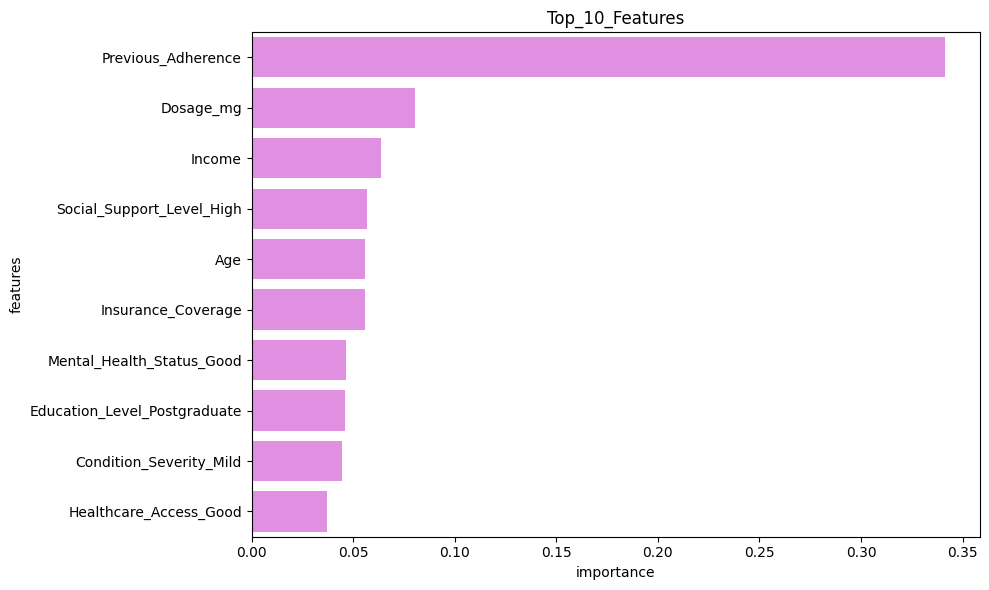

In [21]:
#Feature_importance
best_model = grid1.best_estimator_
preprocessor = best_model.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()
feature_names = [name.split('__')[-1] for name in feature_names]
rf_model = best_model.named_steps['model']
feature_importance = pd.DataFrame({'features':feature_names,'importance':rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values(by = 'importance',ascending=False)
print(feature_importance)
plt.figure(figsize=(10,6))
sns.barplot(y= 'features',x='importance',data = feature_importance.head(10),color= 'violet')
plt.title('Top_10_Features')
plt.tight_layout()
plt.show()

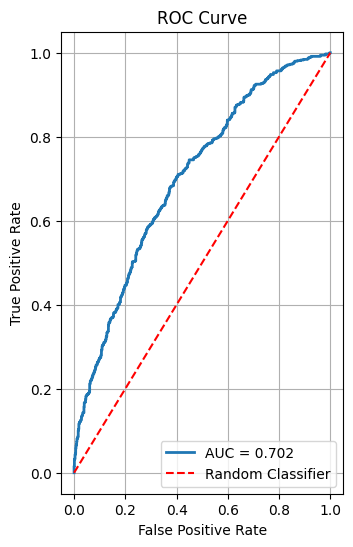

ROC-AUC Score: 0.7020106764110668


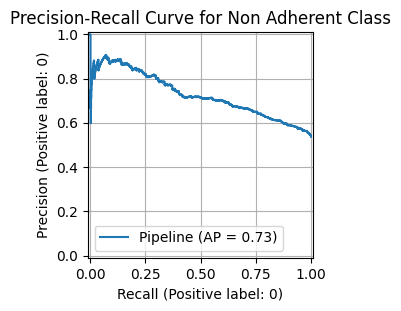

In [22]:
#ROC Curve
best_model = grid1.best_estimator_
y_prob =  best_model.predict_proba(x_test)[:,1]
fpr,tpr,thresholds = roc_curve(y_test,y_prob)
auc_score = roc_auc_score(y_test,y_prob)
# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.subplot(1,2,1)
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'AUC = {auc_score:.3f}'
)

# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='red',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
print("ROC-AUC Score:", auc_score)

#Precision_Recall_Curve
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt
plt.subplot(1,2,2)
PrecisionRecallDisplay.from_estimator(
    best_model,
    x_test,
    y_test,
    pos_label=0,
    ax=plt.gca()
)

plt.title("Precision-Recall Curve for Non Adherent Class")
plt.grid(True)
plt.show()

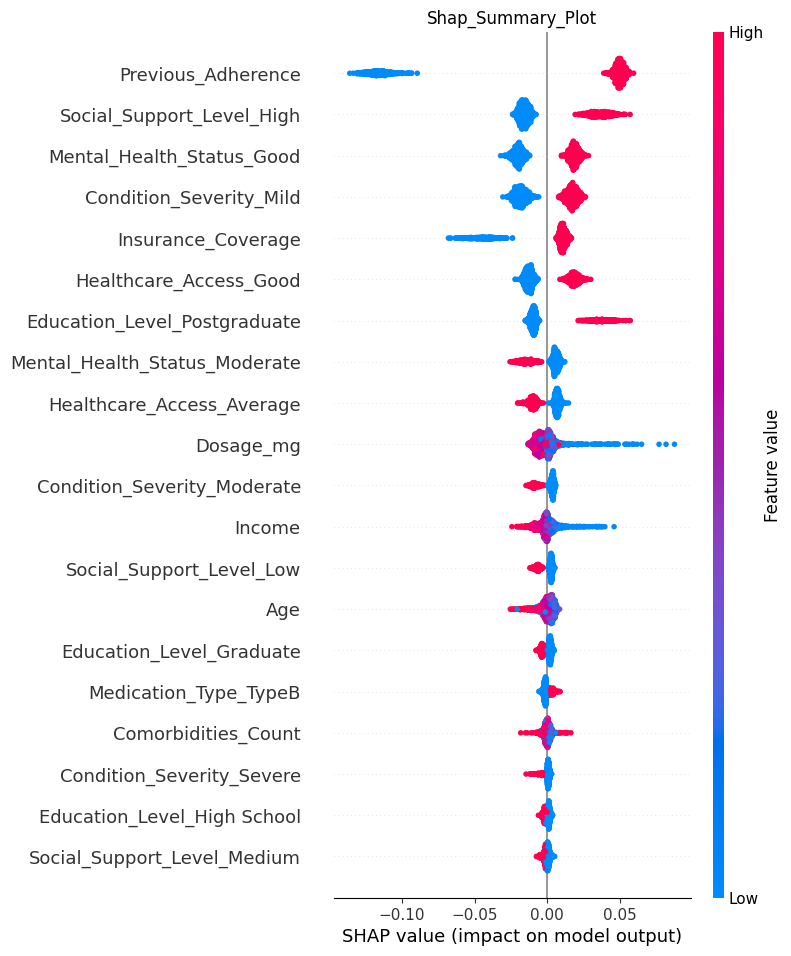

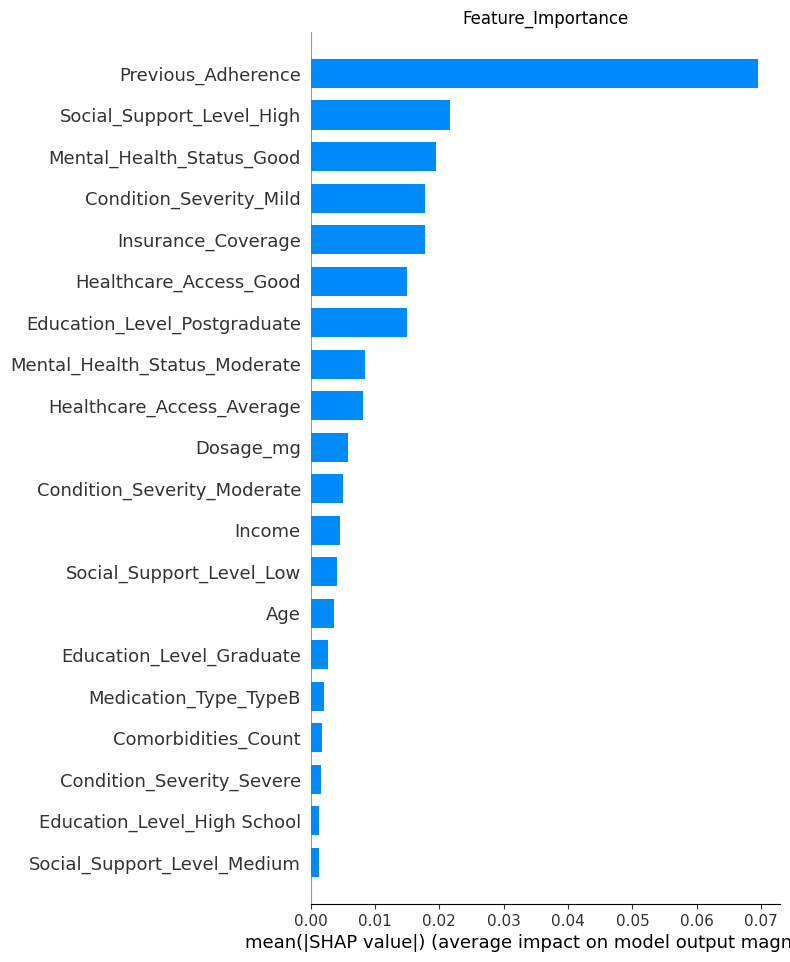

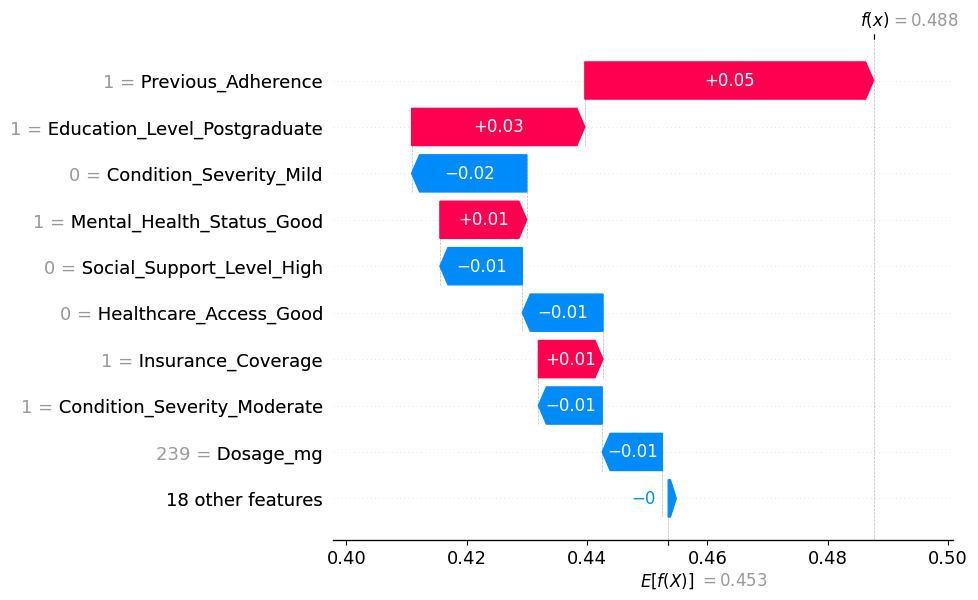

In [23]:
#Shap_Analysis
import shap
preprocessor = best_model.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()
x_train_trans = preprocessor.transform(x_train)
x_test_trans = preprocessor.transform(x_test)
feature_names = [name.split('__')[-1] for name in feature_names]
x_train_trans = pd.DataFrame(x_train_trans,columns = feature_names)
x_test_trans = pd.DataFrame(x_test_trans,columns = feature_names)
rf_model= best_model.named_steps['model']
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(x_test_trans)
plt.figure()
shap.summary_plot(shap_values[:,:,1],x_test_trans,show=False)
plt.title('Shap_Summary_Plot')
plt.show()
plt.figure()
shap.summary_plot(shap_values[:,:,1],x_test_trans,plot_type = 'bar',show= False)
plt.title('Feature_Importance')
plt.show()
sample_index =0
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[sample_index,:,1],
        base_values = explainer.expected_value[1],
        data = x_test_trans.iloc[sample_index],
        feature_names = x_test_trans.columns
    )
)

In [ ]:
import pickle

with open("patient_Adherence_prediction.pkl", "wb") as file:
    pickle.dump(best_model, file)

In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1
